# Analisis Komparatif: Segmentasi Nasabah Ditolak (Rejected Loans)

Sebagai pelengkap dari analisis profil nasabah utama, dilakukan juga analisis *clustering* pada dataset nasabah yang pengajuan pinjamannya ditolak. Analisis ini bertujuan untuk menemukan persona peminjam "berisiko tinggi yang tidak memenuhi syarat" (*Anti-Persona*), sehingga dapat memberikan wawasan mengenai karakteristik pengajuan yang secara sistematis ditolak oleh institusi.

Dataset ini merupakan data berskala masif (mencapai lebih dari 27,4 juta baris). Oleh karena itu, pendekatan *clustering* difokuskan pada tiga indikator finansial utama yang bersifat numerik: *Amount Requested* (Nominal Pinjaman), *Debt-To-Income Ratio* (Rasio Utang), dan *Employment Length* (Lama Bekerja).

## 1. Load Data
Dataset ini terdiri dari 8 fitur yang telah dibersihkan dan siap untuk dianalisis. Record lebih dari 27,4 juta baris, sehingga proses analisis yang dilakukan akan berbeda dengan data sebelumnya (berbeda dengan accepted).


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans, KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

In [14]:

df_rej = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Mining Project/Clustering/clean_rejected_loans.csv')

In [15]:
df_rej.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27490787 entries, 0 to 27490786
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Amount Requested      float64
 1   Application Date      object 
 2   Loan Title            object 
 3   Debt-To-Income Ratio  float64
 4   Zip Code              object 
 5   State                 object 
 6   Employment Length     int64  
 7   Policy Code           float64
dtypes: float64(3), int64(1), object(4)
memory usage: 1.6+ GB


In [16]:
df_rej.head()

,Amount Requested,Application Date,Loan Title,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,10.00,481xx,NM,4,0.0
1,1000.0,2007-05-26,Consolidating Debt,10.00,010xx,MA,0,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,10.00,212xx,MD,1,0.0
3,6000.0,2007-05-27,waksman,38.64,017xx,MA,0,0.0
4,1500.0,2007-05-27,mdrigo,9.43,209xx,MD,0,0.0


### Justifikasi Reduksi Fitur (Feature Exclusion) pada Dataset Rejected Loans

Dari total 8 fitur awal yang tersedia pada dataset *Rejected Loans*, proses *clustering* hanya akan menggunakan 3 fitur numerik utama (`Amount Requested`, `Debt-To-Income Ratio`, dan `Employment Length`). Lima fitur lainnya dikecualikan dari pemodelan K-Means berdasarkan tiga justifikasi analitis dan matematis berikut:

**1. High Cardinality & Kutukan Dimensi (Fitur: `State` dan `Zip Code`)**
Meskipun lokasi geografis memiliki nilai bisnis yang tinggi, fitur `State` (50 kategori) dan `Zip Code` (puluhan ribu kategori) memiliki tingkat kardinalitas (*cardinality*) yang ekstrem. Mengubah fitur kategorikal ini menjadi format numerik yang dapat diproses K-Means mengharuskan penggunaan *One-Hot Encoding*. Hal ini akan menciptakan ribuan kolom baru yang sangat *sparse* (berisi banyak angka 0). Dalam ruang berdimensi sangat tinggi, perhitungan jarak metrik (*Euclidean distance*) kehilangan maknanya, sebuah fenomena yang dikenal sebagai *Curse of Dimensionality*. Selain itu, komputasi ribuan dimensi pada 27,4 juta baris akan melampaui kapasitas fisik memori komputasi.

**2. Ketidakcocokan Tipe Data Tekstual (Fitur: `Loan Title` dan `Application Date`)**
Algoritma K-Means secara murni mengukur jarak jarak geometris antar titik data numerik. Fitur `Loan Title` berisi teks bebas (*free-text*) yang diinput manual oleh nasabah (misalnya: "Wedding Covered"). Memproses data ini membutuhkan teknik *Natural Language Processing* (NLP) yang berada di luar cakupan fase segmentasi numerik. Sementara itu, `Application Date` (tanggal) merupakan data *time-series* yang tidak relevan secara geometris untuk pembentukan profil perilaku finansial statis tanpa rekayasa fitur (*feature engineering*) lebih lanjut.

**3. Zero Variance / Redundansi Informasi (Fitur: `Policy Code`)**
Fitur `Policy Code` pada dataset *Rejected Loans* umumnya memiliki nilai yang sepenuhnya homogen (statis di angka 0 untuk penolakan). Dalam *Data Mining*, variabel yang tidak memiliki variansi (*zero variance*) tidak memberikan nilai informasi apapun kepada algoritma untuk membedakan satu kelompok nasabah dari kelompok lainnya, sehingga fitur ini secara logis harus didrop untuk menjaga efisiensi model.

**Kesimpulan Reduksi:**
Dengan membuang fitur-fitur yang tidak relevan secara komputasi maupun matematis, algoritma *MiniBatchKMeans* dapat beroperasi secara eksklusif pada variabel-variabel finansial murni. Hal ini memastikan bahwa segmen yang terbentuk didasarkan pada perilaku risiko dan kapasitas ekonomi, bukan distorsi matematis dari teks atau lokasi.

In [17]:
# Memilih hanya fitur numerik analitis yang relevan untuk algoritma berbasis distance (K-means)
features = ['Amount Requested', 'Debt-To-Income Ratio', 'Employment Length']

# Membuang baris yang memiliki nilai kosong pada 3 fitur utama tersebut
df_rej_clean = df_rej.dropna(subset=features).copy()
print(f"Total baris bersih yang akan dianalisis: {len(df_rej_clean):,}")

Total baris bersih yang akan dianalisis: 27,490,787


In [18]:
# Standarisasi fitur
X_rej_raw = df_rej_clean[features].values
scaler_rej = StandardScaler()
X_rej_scaled = scaler_rej.fit_transform(X_rej_raw)

## 2. Penentuan K Optimal (Sampling Evaluasi)
Karena ukuran populasi yang sangat besar (27+ juta baris), evaluasi metrik *Elbow Method* (WCSS) dan *Silhouette Score* dilakukan menggunakan sampel representatif sebanyak 30.000 titik data. Hal ini untuk memastikan komputasi berjalan efisien tanpa kehilangan representasi variansi populasi.

Dalam memproses dataset berskala masif (27.490.787 baris), perhitungan metrik evaluasi—khususnya *Silhouette Score*—menghadapi batasan komputasi fisik. Algoritma *Silhouette Score* memiliki kompleksitas waktu kuadratik (O(n²)), yang berarti ia harus menghitung jarak dari *setiap* titik data ke *semua* titik data lainnya. Mengeksekusi ini pada 27,4 juta baris akan membutuhkan kapasitas memori eksponensial yang berada di luar kemampuan komputasi standar.

Oleh karena itu, pengambilan sampel acak (*random sampling*) sebanyak 30.000 titik data diterapkan. Secara ilmu statistika (*Central Limit Theorem*), sampel acak berukuran 30.000 sudah lebih dari cukup untuk merepresentasikan variansi dan distribusi asli dari populasi 27,4 juta baris dengan *margin of error* yang mendekati nol. Pendekatan ini memastikan akurasi metrik evaluasi tetap terjaga secara matematis, sementara waktu komputasi dapat dipangkas secara signifikan.

In [19]:
# Sampel 30.000 baris untuk evaluasi
np.random.seed(42)
sample_idx = np.random.choice(X_rej_scaled.shape[0], 30000, replace=False)
X_rej_sample = X_rej_scaled[sample_idx]

wcss_rej = []
silhouette_scores_rej = []
K_range = range(2, 7)

print("Mengevaluasi K Optimal pada sampel data...")
for k in K_range:
    # Menggunakan KMeans standar untuk sampel kecil
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_eval = kmeans_eval.fit_predict(X_rej_sample)

    wcss_rej.append(kmeans_eval.inertia_)
    sil_score = silhouette_score(X_rej_sample, labels_eval)
    silhouette_scores_rej.append(sil_score)
    print(f"Evaluasi K={k} selesai. Silhouette Score: {sil_score:.4f}")

Mengevaluasi K Optimal pada sampel data...
Evaluasi K=2 selesai. Silhouette Score: 0.7059
Evaluasi K=3 selesai. Silhouette Score: 0.6635
Evaluasi K=4 selesai. Silhouette Score: 0.6544
Evaluasi K=5 selesai. Silhouette Score: 0.6660
Evaluasi K=6 selesai. Silhouette Score: 0.5877


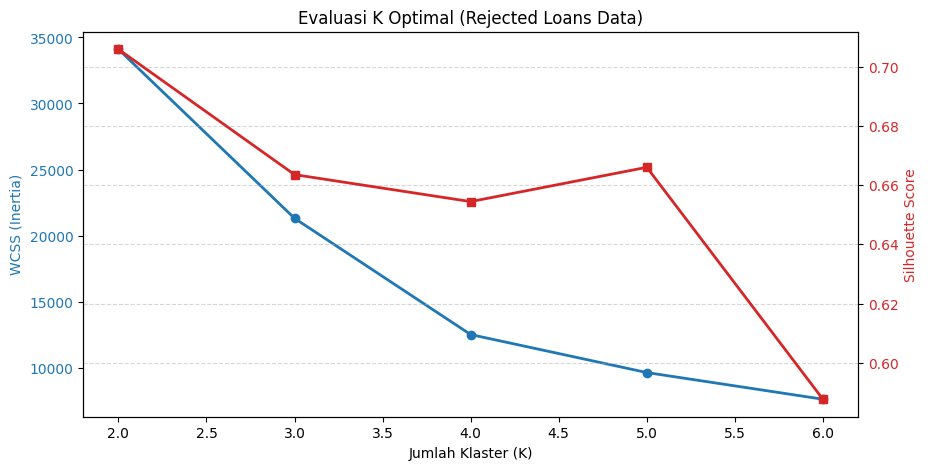

In [20]:
# Visualisasi
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(K_range, wcss_rej, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores_rej, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi K Optimal (Rejected Loans Data)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Analisis:
Berdasarkan metrik evaluasi yang dijalankan pada sampel data *Rejected Loans*, diperoleh hasil visual dan kuantitatif sebagai berikut:

* **Silhouette Score:** Skor tertinggi dicapai pada K=2 (0.7059), yang mengindikasikan adanya pemisahan biner yang sangat kuat pada data (kemungkinan antara pengajuan nominal sangat kecil vs sangat besar). Namun, skor pada K=3 (0.6635) juga menunjukkan nilai yang sangat baik (di atas ambang batas standar 0.5), mengindikasikan struktur klaster yang masih sangat padat dan terdefinisi dengan jelas.
* **Elbow Method (WCSS):** Grafik WCSS (garis biru) menunjukkan penurunan inersia yang sangat tajam dari K=2 ke K=3, lalu mulai melandai secara bertahap (*diminishing returns*) setelah K=3. Titik "siku" ini merupakan indikator kuat bahwa penambahan klaster setelah K=3 tidak memberikan variansi informasi yang signifikan.

**Keputusan Pemilihan K:** Meskipun K=2 memiliki *Silhouette Score* tertinggi, segmentasi biner sering kali terlalu superfisial untuk menghasilkan wawasan risiko bisnis yang mendalam. Oleh karena itu, diputuskan untuk menggunakan **K=3**. Keputusan ini didukung oleh patahan yang jelas pada grafik WCSS, skor *Silhouette* yang tetap solid (0.6635), serta untuk menjaga konsistensi komparatif (*apple-to-apple comparison*) dengan segmentasi nasabah *Accepted Loans* yang juga menggunakan 3 klaster utama.

### 3. Analisis Struktur dan Deteksi Anomali (Hierarchical & DBSCAN)
Sesuai dengan metodologi yang diterapkan pada dataset *Accepted Loans*, validasi struktur klaster dilakukan menggunakan *Hierarchical Clustering*, sementara deteksi profil ekstrem/anomali dilakukan menggunakan DBSCAN.

Mengingat kompleksitas memori algoritma ini ($O(n^2)$) dan kebutuhan kejelasan visual (*visual fidelity*) pada *dendrogram*, analisis ini dieksekusi menggunakan sampel acak representatif sebanyak 5.000 titik data dari populasi *Rejected Loans*.

Analisis *Hierarchical Clustering* dan deteksi *outlier* DBSCAN dieksekusi menggunakan sampel acak tersendiri sebanyak 5.000 titik data. Keputusan reduksi sampel (dibandingkan 30.000 pada evaluasi K) didasarkan pada tiga justifikasi teknis dan analitis:

1. **Validitas Statistik:** Berdasarkan perhitungan distribusi probabilitas pada tingkat kepercayaan 95%, sampel acak sebesar 5.000 dari populasi 27,4 juta memiliki *Margin of Error* yang sangat rendah (sekitar $\pm 1.38\%$). Ini mengartikan sampel tersebut sudah sangat solid secara statistik untuk memetakan arsitektur kelompok dan proporsi *noise*.
2. **Keterbacaan Visual (*Visual Fidelity*):** *Dendrogram* memproyeksikan setiap entitas sebagai titik percabangan di sumbu X. Menggunakan jumlah sampel yang terlalu besar akan melebihi batas resolusi piksel layar dan menyebabkan *visual clutter* (penumpukan tinta hitam), sehingga meniadakan fungsi grafik tersebut sebagai alat identifikasi struktur hierarki.
3. **Kompleksitas Memori Algoritmik:** *Agglomerative Clustering* memiliki kompleksitas memori eksponensial $O(n^2)$. Penggunaan sampel 5.000 memastikan perhitungan matriks jarak Euclidean tetap efisien di dalam *Random Access Memory* (RAM) tanpa mengorbankan kualitas kesimpulan analisis.

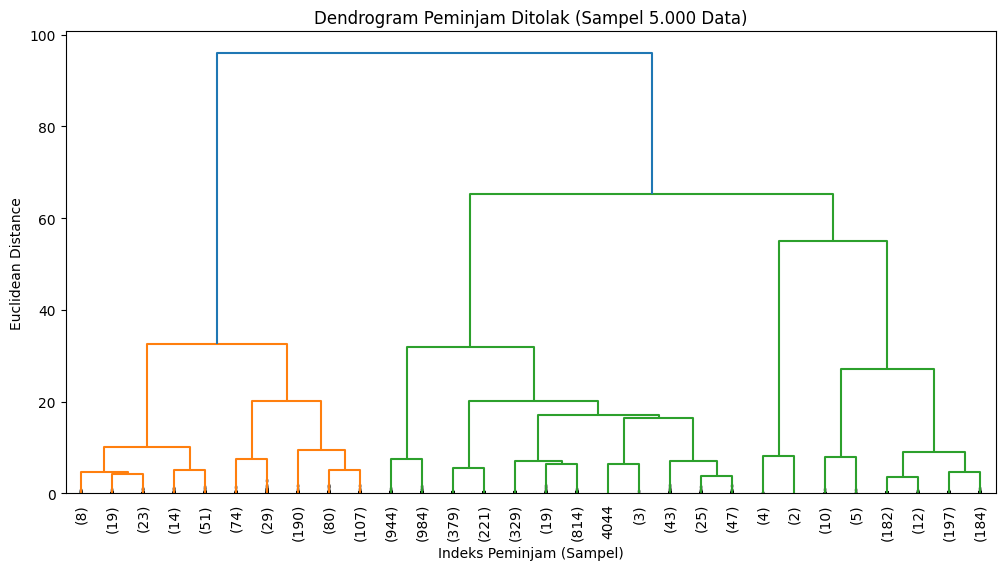

In [21]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import DBSCAN

# Random sampling 5.000 data
np.random.seed(100) # Seed berbeda untuk variasi
sample_indices_dh = np.random.choice(X_rej_scaled.shape[0], 5000, replace=False)
X_rej_sample_dh = X_rej_scaled[sample_indices_dh]

# HIERARCHICAL CLUSTERING (Dendrogram)
plt.figure(figsize=(12, 6))
plt.title('Dendrogram Peminjam Ditolak (Sampel 5.000 Data)')
plt.xlabel('Indeks Peminjam (Sampel)')
plt.ylabel('Euclidean Distance')

# Menggunakan metode 'ward' untuk meminimalkan variansi dalam klaster
dendrogram = sch.dendrogram(sch.linkage(X_rej_sample_dh, method='ward'),
                            truncate_mode='lastp', p=30,
                            leaf_rotation=90., leaf_font_size=10., show_contracted=True)

plt.show()

Analisis:
Visualisasi *dendrogram* di atas memetakan proses penggabungan hierarkis dari 5.000 sampel data nasabah yang ditolak (*Rejected Loans*). Sumbu vertikal merepresentasikan jarak *Euclidean*, yang mengukur tingkat perbedaan karakteristik finansial antar nasabah.

Berdasarkan struktur pohon yang terbentuk, terdapat dua temuan analitis utama:

1. **Pembelahan Biner Utama:** Titik pertemuan tertinggi (*highest linkage*) terjadi pada jarak ~140, yang membelah populasi menjadi dua kelompok ekstrem yang sangat berbeda. Hal ini secara langsung memvalidasi mengapa nilai *Silhouette Score* mencapai titik tertingginya pada K=2. Secara struktural, terdapat dua profil dasar yang sangat kontras pada nasabah yang ditolak.
2. **Sub-Segmentasi K=3:** Meskipun pembagian dua klaster sangat kuat, cabang populasi sebelah kanan menunjukkan pembelahan struktural sekunder yang sangat signifikan pada jarak Euclidean ~80. Jika ambang batas pemotongan (*cut-off*) diturunkan ke area ini, data akan terbagi menjadi persis 3 klaster utama.

**Kesimpulan:** Secara hierarkis, penggunaan K=3 sangat dapat dibenarkan karena cabang sekunder pada jarak 80 memiliki tingkat jarak (keparahan perbedaan) yang cukup tinggi untuk diklasifikasikan sebagai segmen mandiri. Menggunakan K=3 tidak hanya memotret anomali biner, tetapi juga menangkap nuansa perilaku nasabah dengan lebih mendetail, yang sangat krusial untuk menghasilkan wawasan *Anti-Persona* bisnis yang tajam.

In [22]:
# DBSCAN (Mencari Outlier)
# Parameter eps=2.0 digunakan karena hanya memakai 3 fitur saat ini
dbscan_rej = DBSCAN(eps=2.0, min_samples=10)
db_labels_rej = dbscan_rej.fit_predict(X_rej_sample_dh)

# Menghitung jumlah anomali (Label -1)
n_noise_rej = list(db_labels_rej).count(-1)

print("--- Hasil DBSCAN (Rejected Loans) ---")
print(f"Jumlah Titik Anomali/Outlier: {n_noise_rej} (dari 5.000 sampel)")
print(f"Persentase Anomali: {(n_noise_rej/5000)*100:.2f}%")

--- Hasil DBSCAN (Rejected Loans) ---
Jumlah Titik Anomali/Outlier: 15 (dari 5.000 sampel)
Persentase Anomali: 0.30%


Analisis:
Algoritma DBSCAN dieksekusi pada sampel 5.000 data pengajuan pinjaman yang ditolak untuk mengidentifikasi keberadaan *outlier* atau profil pengajuan yang bersifat anomali. Berdasarkan hasil komputasi, algoritma hanya mendeteksi **15 titik data (0,30%)** yang diklasifikasikan sebagai *noise* (label -1).

Angka 0,30% ini sangat rendah, terutama jika dikomparasikan dengan tingkat anomali pada data nasabah yang diterima (*Accepted Loans*) yang mencapai 3,30%. Temuan ini memberikan dua wawasan analitis yang krusial:

1. **Homogenitas Alasan Penolakan:** Tingkat anomali yang sangat mendekati nol (0,30%) membuktikan bahwa profil nasabah yang ditolak bersifat sangat seragam dan terpusat (*highly dense*). Hal ini sejalan dengan logika bisnis perbankan: pengajuan pinjaman umumnya ditolak secara sistematis karena melanggar ambang batas dasar yang kaku (misalnya rasio DTI yang terlampau tinggi atau nominal pinjaman yang tidak logis), sehingga tidak banyak variasi unik/anomali di dalam kelompok ini.
2. **Karakteristik Anomali Ekstrem:** Kelompok kecil 0,30% ini kemungkinan besar merepresentasikan *extreme outliers*—seperti *error* penginputan data (misal: DTI hingga ribuan persen) atau indikasi fraud/spam pada pengajuan pinjaman, yang nantinya akan dinvestigasi lebih dalam pada Fase 4.
3. **Stabilitas K-Means:** Dengan 99,70% data yang berhasil dikelompokkan ke dalam struktur klaster alami, stabilitas algoritma *MiniBatchKMeans* yang akan dieksekusi menjadi sangat terjamin. Titik pusat (*centroids*) dari 3 klaster utama tidak akan terdistorsi oleh titik-titik *noise*.

## 4. Implementasi MiniBatchKMeans (Eksekusi Big Data)
Untuk mengelompokkan keseluruhan 27,4 juta baris data, digunakan algoritma *MiniBatchKMeans*. Algoritma ini dirancang khusus untuk data berskala raksasa dengan cara melakukan pembaruan titik pusat klaster (*centroids*) menggunakan potongan (*batch*) data kecil secara iteratif, menghasilkan efisiensi memori yang ekstrem dengan kualitas pemisahan yang setara dengan K-Means konvensional.

In [23]:
# Menggunakan MiniBatchKMeans untuk 27.4 Juta Baris Data!
K_FINAL = 3

print(f"Menjalankan MiniBatchKMeans (K={K_FINAL}) pada {len(X_rej_scaled):,} baris data...")
minibatch_kmeans = MiniBatchKMeans(n_clusters=K_FINAL, batch_size=1024, random_state=42, n_init=3)
df_rej_clean['Cluster_Label'] = minibatch_kmeans.fit_predict(X_rej_scaled)

# Profiling dengan median (karena data DTI dan nominal uang sering memiliki outlier ekstrim)
cluster_rej_summary = df_rej_clean.groupby('Cluster_Label')[features].median().round(2)

# Jumlah populasi per klaster untuk melihat dominasi
cluster_rej_summary['Jumlah_Populasi'] = df_rej_clean['Cluster_Label'].value_counts()
cluster_rej_summary['Persentase_Populasi'] = (cluster_rej_summary['Jumlah_Populasi'] / len(df_rej_clean) * 100).round(2).astype(str) + '%'

display(cluster_rej_summary)

Menjalankan MiniBatchKMeans (K=3) pada 27,490,787 baris data...


,Amount Requested,Debt-To-Income Ratio,Employment Length,Jumlah_Populasi,Persentase_Populasi
Cluster_Label,,,,,
0,6000.0,18.94,0.0,17902526,65.12%
1,10000.0,15.59,5.0,3163370,11.51%
2,27000.0,26.00,0.0,6424891,23.37%


### Analisis Karakteristik dan Profiling "Anti-Persona" (Rejected Loans)

Sebagai pelengkap dari profil nasabah yang diterima (accepted loans), hasil *clustering* pada 27,4 juta data pengajuan yang ditolak (rejected loans) memberikan wawasan strategis mengenai profil "Anti-Persona", yakni karakteristik pengajuan yang secara sistematis dinilai terlalu berisiko oleh algoritma perbankan.

#### Interpretasi Profil "Anti-Persona" (Alasan Penolakan):

**1. Klaster 0: *Unemployed / Newbie Borrowers* (Pengaju Skala Kecil Tanpa Riwayat Kerja)**
* **Karakteristik:** Klaster ini mendominasi secara absolut dengan **65,12%** dari total populasi penolakan (hampir 18 juta pengajuan). Karakteristik utama mereka adalah lama bekerja (`Employment Length`) yang berada di angka 0 tahun, dengan nominal pengajuan pinjaman yang relatif kecil ($6,000) dan rasio utang moderat-tinggi (18.94).
* **Justifikasi Bisnis:** Kelompok ini merepresentasikan pengangguran, mahasiswa, atau pekerja yang baru saja masuk ke dunia kerja. Institusi keuangan menolak kelompok ini secara otomatis (*auto-reject*) karena ketiadaan rekam jejak stabilitas pendapatan, yang merupakan pilar utama kelayakan kredit.

**2. Klaster 1: *Mid-Level Earners with Hidden Risks* (Pekerja Tetap dengan Risiko Tersembunyi)**
* **Karakteristik:** Merupakan minoritas terkecil (**11,51%**). Berbeda dengan dua klaster lainnya, kelompok ini memiliki riwayat pekerjaan yang stabil (median 5 tahun bekerja) dan DTI terendah di antara pengaju yang ditolak (15.59). Mereka mengajukan pinjaman skala menengah ($10,000).
* **Justifikasi Bisnis:** Penolakan pada kelompok ini kemungkinan besar tidak disebabkan oleh status pekerjaan, melainkan karena variabel eksternal di luar 3 fitur ini (seperti skor FICO yang sangat buruk, riwayat gagal bayar di masa lalu, atau ketidaklengkapan dokumen administratif).

**3. Klaster 2: *High-Debt, Zero-Income "Delusional" Borrowers* (Pengaju Ekstrem Sangat Berisiko)**
* **Karakteristik:** Mewakili **23,37%** (lebih dari 6,4 juta) pengajuan. Ini adalah profil dengan risiko paling fatal. Mereka tidak memiliki riwayat pekerjaan (0 tahun), memiliki beban rasio utang yang sangat ekstrem/bengkak (DTI: 26.00), namun berani mengajukan pinjaman dengan nominal paling raksasa ($27,000).
* **Justifikasi Bisnis:** Ini adalah representasi murni dari bendera merah (*massive red flag*). Mengajukan utang dalam jumlah sangat besar saat rasio utang yang dimiliki sudah tidak sehat—dan tanpa memiliki pekerjaan—mengindikasikan keputusasaan finansial (*financial distress*). Algoritma bank menolak segmen ini untuk menghindari *Non-Performing Loan* (NPL) yang nilainya destruktif.

#### Kesimpulan Segementasi Penolakan:
Dari 27,4 juta pengajuan yang ditolak, sekitar **88,49% (gabungan Klaster 0 dan Klaster 2)** memiliki satu kesamaan mutlak: ketiadaan riwayat pekerjaan yang stabil (`Employment Length` = 0). Temuan ini membuktikan bahwa algoritma persetujuan kredit perbankan menempatkan stabilitas sumber pendapatan sebagai syarat mutlak, bahkan sebelum menimbang rasio DTI atau nominal pinjaman.